In [9]:
import numpy as np
import pandas as pd
from history import Polygon
import sys
sys.path.append('/Users/moilanen/sbx/paragon/lib')
sys.path.append('/Users/moilanen/sbx/paragon/data')
sys.path.append('/Users/moilanen/sbx/paragon/data/provider')
sys.path.append('.')

# Backtester Libraries
import matplotlib.pyplot as plt
import datetime
from talib.abstract import *
import pinkfish as pf

import math
from datetime import datetime, timedelta, date

from support_resistance import sr

np.seterr(all='ignore')


benchmark_stock = 'QQQ' # Must be in the stocks list

stocks = [
        'AAL',
        'AAPL',
        'ABBV',
        'ADBE',
        'AMD',
        'AMZN',
        'AVGO',
        'BA',
        'BABA',
        'BAC',
        'BYND',
        'CAT',
        'CGC',
        'CLF',
        'COST',
        'CRM',
        'DBX',
        'DIS',
        'DKNG',
        'DOCU',
        'EDIT',
        'ETSY',
        'F',
        'FB',
        'FXI',
        'GOOGL',
        'HD',
        'HON',
        'IQ',
        'INTC',
        'IWM',
        'JD',
        'LULU',
        'LLY',
        'LYFT',
        'MSFT',
        'MU',
        'NFLX',
        'NIO',
        'NKE',
        'NKLA',
        'NOW',
        'NVDA',
        'ORCL',
        'PENN',
        'PINS',
        'PFE',
        'PM',
        'PTON',
        'PYPL',
        'QCOM',
        'QQQ',
        'ROKU',
        'SBUX',
        'SHOP',
        'SLB',
        'SNAP',
        'SPY',
        'SPCE',
        'SQ',
        'TDOC',
        'TLRY',
        'TSLA',
        'TTD',
        'TTWO',
        'TWLO',
        'TWTR',
        'UA',
        'UBER',
        'WMT',
        'WYNN',
        'XLF',
        'ZM',
        'ZNGA'
                  ]

stocks = ['AAL', 'ADBE', 'AMD', 'BABA', 'C', 'AMZN', 'GOOGL', 'MSFT', 'SPCE', 'FB', 'ARKK', 'SLV', 'ZM','TWTR', 'SQ', 'TWLO', 'NVDA']
#stocks = ['AMD','NFLX', 'AMZN' ]

num_days = 250
capital = 100000

# start_date = date.today() - timedelta(days = math.ceil((num_days/(5/7))))
# start_date_long = date.today() - timedelta(days = math.ceil((num_days*5/(5/7))))
# end_date = datetime.now()

start_date = datetime(2020, 10, 1, 1, 1, 1, 1)
start_date_long = datetime(2020, 6, 1, 1, 1, 1, 1)
end_date = datetime(2021, 10, 1, 1, 1, 1, 1)


start_date
end_date

datetime.datetime(2021, 10, 1, 1, 1, 1, 1)

In [10]:
# Pull Data

ohlcvs = {}
ohlcvs_short = {}
ohlcvs_long = {}

polygon = Polygon()

timeframe_short = '5m'
periods_day_short = int(390/5)

timeframe = '30m'
periods_day = int(390/30)

timeframe_long = '1d'
periods_day_long = 1

    
for stock in stocks:
    print("------ %s ------" % (stock))
    ohlcv = polygon.history_aggregate(stock, int(periods_day_short*num_days), timeframe_short, start_date, after_hours = False)
    ohlcvs_short[stock] = ohlcv

    ohlcv = polygon.history_aggregate(stock, int(periods_day*num_days), timeframe, start_date, after_hours = False)
    ohlcvs[stock] = ohlcv

    ohlcv = polygon.history_aggregate(stock, int(periods_day_long*num_days*5), timeframe_long, start_date_long, after_hours = False)
    ohlcvs_long[stock] = ohlcv



------ AAL ------
Polygon history_aggregate does not have enough data. Want: 1250 Have: 344 DF:                                 volume    vw  open  close  high   low
t                                                                    
2020-06-01 00:00:00-04:00  50681544.00 11.11 10.79  11.11 11.33 10.62
2020-06-02 00:00:00-04:00  49115215.00 11.25 11.40  11.22 11.64 10.97
2020-06-03 00:00:00-04:00  86680112.00 11.86 11.56  11.85 12.20 11.44
2020-06-04 00:00:00-04:00 399405920.00 15.44 12.85  16.72 18.18 12.63
2020-06-05 00:00:00-04:00 428583855.00 20.05 21.25  18.59 22.80 17.80
...                                ...   ...   ...    ...   ...   ...
2021-10-04 00:00:00-04:00  28623357.00 21.56 21.91  21.39 22.08 21.29
2021-10-05 00:00:00-04:00  22580145.00 21.51 21.50  21.47 21.85 21.25
2021-10-06 00:00:00-04:00  37908541.00 20.53 20.70  20.54 21.01 20.31
2021-10-07 00:00:00-04:00  29167184.00 20.40 20.84  20.17 20.90 20.08
2021-10-08 00:00:00-04:00  15025291.00 20.05 20.24  20.05 20.29 

Polygon history_aggregate does not have enough data. Want: 1250 Have: 344 DF:                                volume    vw  open  close  high   low
t                                                                   
2020-06-01 00:00:00-04:00 22963678.00 17.88 18.36  17.52 18.70 17.26
2020-06-02 00:00:00-04:00 24561451.00 16.11 16.89  15.82 16.89 15.76
2020-06-03 00:00:00-04:00 30512328.00 16.02 15.35  16.39 16.79 15.20
2020-06-04 00:00:00-04:00 13710667.00 16.05 16.21  15.86 16.44 15.76
2020-06-05 00:00:00-04:00 13351388.00 15.97 16.21  15.77 16.27 15.66
...                               ...   ...   ...    ...   ...   ...
2021-10-04 00:00:00-04:00 10849543.00 22.83 23.62  22.73 23.72 22.54
2021-10-05 00:00:00-04:00  9055180.00 22.44 22.79  22.53 22.88 21.96
2021-10-06 00:00:00-04:00  9677773.00 22.88 22.53  22.98 23.31 22.31
2021-10-07 00:00:00-04:00  6855661.00 23.32 23.03  23.21 23.66 22.84
2021-10-08 00:00:00-04:00  2981674.00 23.34 23.19  23.23 23.74 23.01

[344 rows x 6 columns]
-

Polygon history_aggregate does not have enough data. Want: 1250 Have: 344 DF:                                volume     vw   open  close   high    low
t                                                                       
2020-06-01 00:00:00-04:00 39051100.00  87.75  88.33  88.06  88.41  86.89
2020-06-02 00:00:00-04:00 39132056.00  87.51  87.96  88.25  88.37  86.58
2020-06-03 00:00:00-04:00 35943888.00  87.70  88.22  87.69  88.66  87.00
2020-06-04 00:00:00-04:00 42427840.00  88.00  87.28  87.67  89.43  86.78
2020-06-05 00:00:00-04:00 48174604.00  88.85  87.94  89.20  89.97  87.08
...                               ...    ...    ...    ...    ...    ...
2021-10-04 00:00:00-04:00 34563497.00 198.20 205.04 197.32 205.42 195.55
2021-10-05 00:00:00-04:00 27928165.00 203.79 199.50 204.51 206.48 198.54
2021-10-06 00:00:00-04:00 29720175.00 205.23 201.20 207.00 207.20 200.80
2021-10-07 00:00:00-04:00 25691893.00 211.51 210.92 210.75 213.22 209.72
2021-10-08 00:00:00-04:00  8947057.00 210.22 2

In [11]:
ohlcvs_long[stock]

,volume,vw,open,close,high,low
t,,,,,,
2020-06-01 00:00:00-04:00,39051100.00,87.75,88.33,88.06,88.41,86.89
2020-06-02 00:00:00-04:00,39132056.00,87.51,87.96,88.25,88.37,86.58
2020-06-03 00:00:00-04:00,35943888.00,87.70,88.22,87.69,88.66,87.00
2020-06-04 00:00:00-04:00,42427840.00,88.00,87.28,87.67,89.43,86.78
2020-06-05 00:00:00-04:00,48174604.00,88.85,87.94,89.20,89.97,87.08
...,...,...,...,...,...,...
2021-10-04 00:00:00-04:00,34563497.00,198.20,205.04,197.32,205.42,195.55
2021-10-05 00:00:00-04:00,27928165.00,203.79,199.50,204.51,206.48,198.54
2021-10-06 00:00:00-04:00,29720175.00,205.23,201.20,207.00,207.20,200.80


In [12]:
import datetime
import pinkfish as pf

# format price data
pd.options.display.float_format = '{:0.2f}'.format

In [37]:
import talib

def _print(msg):
    if False:
        print(msg)

def handle_data(df, df_long, price_for_stop, quantity_total, quantity_start, price_high_water, price_avg, stop_loss_atr_stds = 20.0, price_target_multiple = 0.75, profit_to_risk = 0.2, pop_std = 2, scale_out = 0.5):
    sma_small = 9
    sma_big = 21

#     print("---- Stop Loss ATR STDs: %0.2f Price Target Multiple: %0.2f" % (stop_loss_atr_stds, price_target_multiple))

#     print("Quantity Total: %d Start: %d" % (quantity_total, quantity_start))

    price = df.iloc[-1]['close']
    timeperiod = 14

    if True:
        atr = talib.ATR(df_long['high'].to_numpy(), df_long['low'].to_numpy(), df_long['close'].to_numpy(), timeperiod = timeperiod)
        atr = atr[~np.isnan(atr)]
        atr_std = np.std(atr)
    else:
        df['atr'] = talib.ATR(df['high'].to_numpy(), df['low'].to_numpy(), df['close'].to_numpy(), timeperiod = timeperiod)
        df['atr_std'] = df['atr'].rolling(timeperiod).std()

    idx = df.index.searchsorted(ohlcv.index, side='left') - 1

    df['sma_small'] = df['close'].rolling(sma_small).mean()
    df['sma_big'] = df['close'].rolling(sma_big).mean()

    df['adx'] = talib.ADX(df['high'], df['low'], df['close'])
#     df = df.dropna(axis=0)
    
    last = df.iloc[-1]
    price_current = last['close']

    atr = atr[-1]
    atrp = atr_std / last['close']

    
    # Opening
    if quantity_total == 0 and last['sma_small'] > last['sma_big']:
        return quantity_start, last['close']
    
    # Nothing to do yet
    if quantity_total == 0:
        return 0, 0.0

    profit_per_share = price_high_water - price_avg
    profit_per_share_current = price_current - price_avg
    if True:
        # How much room we need to give on the upside
        risk = (atr + (atr_std * price_target_multiple))

        # Increase that room for us to risk some of our profit
        profit_needed = (risk / (1.0 - profit_to_risk))
    else:
        risk = (atr + (atr_std * price_target_multiple))
        profit_needed = (risk / profit_to_risk)

    profit_after_risk = profit_per_share - profit_needed
    
    _print("Profit Per Share: %0.2f Total Profit: %0.2f" % (profit_per_share_current, profit_per_share_current * quantity_total))
    
    # Figure out stop loss
    if quantity_total == quantity_start:
        # Initial Stop Loss before a scale in
        stop_loss_amount = (atr + (atr_std * stop_loss_atr_stds))
        stop_loss = price_avg - stop_loss_amount
        target = price_avg + profit_needed
        
        _print("Set Stop Loss: %0.2f Target: %0.2f price_avg: %0.2f stop_loss_amount: %0.2f profit_needed: %0.2f" % (stop_loss, target, price_avg, stop_loss_amount, profit_needed))
    else:
        # After have scaled in, don't want to give up too much profit
        stop_loss_amount = profit_per_share * profit_to_risk
        stop_loss = price_high_water - stop_loss_amount
        target = False
        _print("Update Stop Loss: %0.2f price_avg: %0.2f target/price_high_water: %0.2f stop_loss_amount: %0.2f" % (stop_loss, price_avg, price_high_water, stop_loss_amount))

    # Check if stopped out
    dt = df.iloc[-1].name
    if price_for_stop is not False and price_for_stop <= stop_loss and (dt.time() >= datetime.time(10, 30) or quantity_total != quantity_start):
        _print("Stop Out: %0.2f" % (stop_loss))
        return -quantity_total, min(stop_loss, last['open'])

    # Scale out Pops
    last_tr = max([last['high'] - last['low'], last['high'] - df.iloc[-2]['close'], df.iloc[-2]['close'] - last['low']])

#     if target is False and (last_tr - last['atr']) / last['atr_std'] >= pop_std:
#         _print("Scale Out: %d Last TR: %0.2f" % (-math.floor(quantity_total * scale_out), last_tr))
#         return -math.floor(quantity_total * scale_out), last['close']
    
    if last['close'] >= target or target == False:
        _print("Target Hit: Scale in: %0.2f" % (target))
#         stop_loss_atr_std = (profit_after_risk - last['atr']) / last['atr_std']
#         _print("Stop Loss ATR Std: %0.2f\tProfit Per Share: %0.2f Profit At Risk: %0.2f Stop Loss Amount: %0.2f Last ATR: %0.2f Last ATR STD: %0.2f" % (stop_loss_atr_std, profit_per_share, profit_at_risk, stop_loss_amount, last['atr'], last['atr_std']))
#         std_above = stop_loss_atr_std * price_target_multiple
        std_above = 0.0
        _print("Stop Loss Amount: %0.2f Price Target Multiple: %0.2f Stop Loss ATR Std: %0.2f Std Above: %0.2f" % (stop_loss_amount, price_target_multiple, stop_loss_atr_stds, std_above))
        if profit_after_risk > 0:
            price_avg_target = price_high_water - profit_needed
            price_delta = price_current - price_avg_target
            shares_need = int((price_current * quantity_total) - (price_avg * quantity_total) - (price_delta * quantity_total)) / (price_current - price_avg_target)

            _print("Price Current: %0.2f\tPrice Target: %0.2f\tPrice Avg: %0.2f\tPrice Delta: %0.2f\tShares Needed: %d" % (price_current, price_avg_target, price_avg, price_delta, shares_need))
            if shares_need < 0:
                return 0, 0.0
            
            return shares_need, price_current
    
    return 0, 0.0
    


    
    

In [41]:
import datetime
# def run(stocks, ohlcvs, stop_loss_atr_stds = 20.0, price_target_multiple = 0.75, quantity_multiple = 2, stop_loss_profit = 0.20):
def run(params):
    stocks = params['stocks']
    ohlcvs = params['ohlcvs']
    ohlcvs_short = params['ohlcvs_short']
    ohlcvs_long = params['ohlcvs_long']
    profit_to_risk = params['profit_to_risk']
    stop_loss_ma = params['stop_loss_ma']
    stop_loss_atr_stds = params['stop_loss_atr_stds']
    price_target_multiple = params['price_target_multiple']
    pop_std = params['pop_std']
    scale_out = params['scale_out']
    lookback = 50
  
    print("---- SL ATR STDs: %0.2f PT Multiple: %0.2f SL MA: %d Profit to Risk: %0.2f Pop STD: %0.2f Scale Out: %0.1f%%" % (stop_loss_atr_stds, price_target_multiple, stop_loss_ma, profit_to_risk*100.0, pop_std, scale_out*100.0))

    num_companies = len(stocks)
    benchmark_start_date = False

    portfolio_values = {}
    sortinos = []
    
    for stock in stocks:
#         print("-------- %s --------" % (stock))

        tlog = pf.TradeLog(stock, reset=True)
        dbal = pf.DailyBal()

        df = ohlcvs[stock]
        df_short = ohlcvs_short[stock]
        df_long = ohlcvs_long[stock]
        quantity_total = 0
        price_high_water = 0.0
        entry_price_average = 0.0

        pf.TradeLog.cash = capital

        for i in range(lookback, len(df)):
            df_tmp = df.iloc[i-lookback:i].dropna(axis=1)
            dt = df_tmp.iloc[-1].name
            last = df_tmp.iloc[-1]

            prices_long_index = df_long.index.searchsorted(dt)+1
            df_long_tmp = df_long.iloc[0:prices_long_index] # Fix me

            prices_short_index = df_short.index.searchsorted(dt)+1
#             print("------")
#             print("Point: %s" % str(dt))
#             print(str(df_short.iloc[prices_short_index-stop_loss_ma:prices_short_index]))
#             df_short_tmp = df_short.iloc[prices_short_index-stop_loss_ma:prices_short_index] # Fix me

            
            # Skip first hour of the day
#             if dt.time() < datetime.time(10, 30):
#                 price_for_stop = False
#                 continue

#             print(str(dt.time()))

            # Only update quantity_start when we're starting. 
            if quantity_total == 0:
                quantity_start = int(capital / last['close'])

            if True:
                price_for_stop = last['close']
            else:
                if quantity_total != 0 and quantity_total != quantity_start:
                    price_for_stop = df_short.iloc[prices_short_index-stop_loss_ma:prices_short_index]['close'].mean()
                else:
                    price_for_stop = last['close']

                
#             print("Price For Stop: %0.2f" % (price_for_stop))
                
                
            if benchmark_start_date is False:
                benchark_start_date = dt
    #         print(str(i)+" "+str(df_tmp.iloc[-1].name)+" Close: "+str(last.close)+" High: "+str(last.high)+" Low: "+str(last.low)+" Open: "+str(last.open))

            quantity, price_event = handle_data(df_tmp, df_long_tmp, price_for_stop, quantity_total, quantity_start, price_high_water, entry_price_average, stop_loss_atr_stds = stop_loss_atr_stds, price_target_multiple = price_target_multiple, profit_to_risk = profit_to_risk)

            if i == len(df)-1:
                quantity = -quantity_total
                price_event = last.close

            if quantity > 0:
                _print("Buy: Have: %d Want: %d Price: %0.2f" % (quantity_total, quantity, price_event))
                tlog.buy(dt, price_event, shares = quantity)
                entry_price_average = ((entry_price_average * quantity_total) + (quantity * price_event)) / (quantity_total + quantity)

            if quantity < 0:
                _print("Sell: Have: %d Price: %0.2f" % (quantity_total, price_event))
                tlog.sell(dt, price_event, shares = -quantity)

                if quantity_total == -quantity:
                    price_high_water = 0.0
                    entry_price_average = 0.0

            quantity_total += quantity

            if quantity_total > 0:
                price_high_water = max(price_high_water, last['high'])


            dbal.append(dt, last.high, last.low, last.close)


        tlog_ = tlog.get_log()
        dbal_ = dbal.get_log(tlog_)
        stats = pf.stats(df, tlog_, dbal_, capital)
        print("[%s] Sortino: %0.2f" % (stock, stats.sortino_ratio))
#         print(str(stats))

        portfolio_values[stock] = dbal_['close']
        # Remove nans
        if stats.sortino_ratio == stats.sortino_ratio and math.isinf(stats.sortino_ratio) is False:
            sortinos.append(stats.sortino_ratio)
    
    if len(sortinos) > 0:
        sortino_ratio = sum(sortinos)/len(sortinos)
    else:
        sortino_ratio = 0.0
    print("Final: %0.2f" % (sortino_ratio))
    
    return portfolio_values, sortino_ratio
    

params = {
    "stocks": stocks,
    "ohlcvs": ohlcvs,
    "stop_loss_atr_stds": 21.5,
    "price_target_multiple": 2.65,
    "stop_loss_ma": 5,
    "profit_to_risk": 0.28,
    "pop_std": 2.0,
    "scale_out": 0.75
} 

#15.357617047703647, 0.25776519150612365, 9, 0.0677
# 3.9054160953004122, 0.2977502942728495, 20, 0.1458055969859279
params = {
    "stocks": stocks,
    "ohlcvs": ohlcvs,
    "ohlcvs_short": ohlcvs_short,
    "ohlcvs_long": ohlcvs_long,
    "stop_loss_atr_stds": 3.78,
    "price_target_multiple": -1.0,
    "stop_loss_ma": 5,
    "profit_to_risk": 0.15,
    "pop_std": 2.0,
    "scale_out": 0.75
}    


portfolio_values, sortinos = run(params)

---- SL ATR STDs: 3.78 PT Multiple: -1.00 SL MA: 5 Profit to Risk: 15.00 Pop STD: 2.00 Scale Out: 75.0%
[AAL] Sortino: 0.62
[ADBE] Sortino: 0.31
[AMD] Sortino: 0.35
[BABA] Sortino: -0.40
[C] Sortino: 1.13
[AMZN] Sortino: 0.06
[GOOGL] Sortino: 0.88
[MSFT] Sortino: 0.39
[SPCE] Sortino: 0.90
[FB] Sortino: 0.35
[ARKK] Sortino: 0.36
[SLV] Sortino: 0.15
[ZM] Sortino: -0.25
[TWTR] Sortino: 0.50
[SQ] Sortino: 0.36
[TWLO] Sortino: 0.24
[NVDA] Sortino: 0.44
Final: 0.38


In [39]:
import skopt

SPACE = [
        skopt.space.Real(0.1, 4.0, name='stop_loss_atr_stds', prior='uniform'),
        skopt.space.Real(-3.0, 3.0, name='price_target_multiple', prior='uniform'),
#         skopt.space.Integer(2, 21, name='stop_loss_ma', prior='uniform'),
        skopt.space.Real(0.05, 0.5, name='profit_to_risk', prior='uniform'),
#         skopt.space.Real(1.5, 3.5, name='pop_std', prior='uniform'),
#         skopt.space.Real(0.05, 0.95, name='scale_out', prior='uniform')         
         ]

N_ROWS=10000
STATIC_PARAMS = {
    'stocks': stocks, 
    'ohlcvs': ohlcvs,
    "ohlcvs_short": ohlcvs_short,    
    "ohlcvs_long": ohlcvs_long,
#     "stop_loss_atr_stds": 21.5,
#     "price_target_multiple": 2.65,    
#     'profit_to_risk': 0.28,
    'stop_loss_ma': 5,
    'pop_std': 0.75,
    'scale_out': 0.2
}
HPO_PARAMS = {'n_calls':100,
              'n_random_starts':10,
              'base_estimator':'ET',
              'acq_func':'EI',
              'xi':0.02,
              'kappa':1.96,
              'n_points':10000,
             }

experiment_params = {**STATIC_PARAMS, 
                     **HPO_PARAMS,
                     'n_rows': N_ROWS
                    }

@skopt.utils.use_named_args(SPACE)
def objective(**params):
    all_params = {**params, **STATIC_PARAMS}
    portfolio_values, sortino = run(all_params)    
    return -1.0 * sortino


results = skopt.forest_minimize(objective, SPACE, **HPO_PARAMS)
best_auc = -1.0 * results.fun
best_params = results.x


    
# log metrics
print('Best Validation AUC: {}'.format(best_auc))
print('Best Params: {}'.format(best_params))



---- SL ATR STDs: 2.23 PT Multiple: -2.56 SL MA: 5 Profit to Risk: 35.35 Pop STD: 0.75 Scale Out: 20.0%
[AAL] Sortino: 0.73
[ADBE] Sortino: 0.33
[AMD] Sortino: 0.39
[BABA] Sortino: -0.40
[C] Sortino: 1.05
[AMZN] Sortino: 0.05
[GOOGL] Sortino: 0.78
[MSFT] Sortino: 0.43
[SPCE] Sortino: 1.02
[FB] Sortino: 0.30
[ARKK] Sortino: 0.42
[SLV] Sortino: 0.03
[ZM] Sortino: -0.05
[TWTR] Sortino: 0.56
[SQ] Sortino: 0.44
[TWLO] Sortino: 0.25
[NVDA] Sortino: 0.32
Final: 0.39
---- SL ATR STDs: 1.11 PT Multiple: -2.61 SL MA: 5 Profit to Risk: 13.12 Pop STD: 0.75 Scale Out: 20.0%
[AAL] Sortino: 0.97
[ADBE] Sortino: 0.16
[AMD] Sortino: 0.49
[BABA] Sortino: -0.33
[C] Sortino: 1.27
[AMZN] Sortino: 0.13
[GOOGL] Sortino: 0.89
[MSFT] Sortino: 0.39
[SPCE] Sortino: 0.99
[FB] Sortino: 0.46
[ARKK] Sortino: 0.38
[SLV] Sortino: 0.09
[ZM] Sortino: -0.03
[TWTR] Sortino: 0.63
[SQ] Sortino: 0.49
[TWLO] Sortino: 0.41
[NVDA] Sortino: 0.32
Final: 0.45
---- SL ATR STDs: 1.08 PT Multiple: 2.76 SL MA: 5 Profit to Risk: 14.70 

[ARKK] Sortino: 0.49
[SLV] Sortino: -0.07
[ZM] Sortino: 0.07
[TWTR] Sortino: 0.66
[SQ] Sortino: 0.64
[TWLO] Sortino: 0.37
[NVDA] Sortino: 0.47
Final: 0.48
---- SL ATR STDs: 0.34 PT Multiple: -2.95 SL MA: 5 Profit to Risk: 15.81 Pop STD: 0.75 Scale Out: 20.0%
[AAL] Sortino: 1.04
[ADBE] Sortino: 0.33
[AMD] Sortino: 0.64
[BABA] Sortino: -0.31
[C] Sortino: 1.09
[AMZN] Sortino: 0.18
[GOOGL] Sortino: 0.92
[MSFT] Sortino: 0.27
[SPCE] Sortino: 1.17
[FB] Sortino: 0.33
[ARKK] Sortino: 0.45
[SLV] Sortino: -0.07
[ZM] Sortino: 0.09
[TWTR] Sortino: 1.12
[SQ] Sortino: 0.64
[TWLO] Sortino: 0.45
[NVDA] Sortino: 0.54
Final: 0.52
---- SL ATR STDs: 0.19 PT Multiple: -2.97 SL MA: 5 Profit to Risk: 6.19 Pop STD: 0.75 Scale Out: 20.0%
[AAL] Sortino: 0.97
[ADBE] Sortino: 0.31
[AMD] Sortino: 0.70
[BABA] Sortino: -0.32
[C] Sortino: 1.10
[AMZN] Sortino: 0.27
[GOOGL] Sortino: 0.85
[MSFT] Sortino: 0.25
[SPCE] Sortino: 0.87
[FB] Sortino: 0.44
[ARKK] Sortino: 0.41
[SLV] Sortino: -0.02
[ZM] Sortino: 0.12
[TWTR] Sorti

[BABA] Sortino: -0.32
[C] Sortino: 1.19
[AMZN] Sortino: 0.08
[GOOGL] Sortino: 0.80
[MSFT] Sortino: 0.35
[SPCE] Sortino: 0.97
[FB] Sortino: 0.36
[ARKK] Sortino: 0.72
[SLV] Sortino: -0.03
[ZM] Sortino: -0.02
[TWTR] Sortino: 0.64
[SQ] Sortino: 0.58
[TWLO] Sortino: 0.34
[NVDA] Sortino: 0.36
Final: 0.46
---- SL ATR STDs: 3.58 PT Multiple: -2.95 SL MA: 5 Profit to Risk: 42.83 Pop STD: 0.75 Scale Out: 20.0%
[AAL] Sortino: 0.67
[ADBE] Sortino: 0.35
[AMD] Sortino: 0.29
[BABA] Sortino: -0.38
[C] Sortino: 1.13
[AMZN] Sortino: 0.09
[GOOGL] Sortino: 0.87
[MSFT] Sortino: 0.47
[SPCE] Sortino: 0.80
[FB] Sortino: 0.31
[ARKK] Sortino: 0.35
[SLV] Sortino: 0.01
[ZM] Sortino: -0.17
[TWTR] Sortino: 0.56
[SQ] Sortino: 0.48
[TWLO] Sortino: 0.26
[NVDA] Sortino: 0.26
Final: 0.37
---- SL ATR STDs: 0.16 PT Multiple: -2.95 SL MA: 5 Profit to Risk: 45.81 Pop STD: 0.75 Scale Out: 20.0%
[AAL] Sortino: 0.92
[ADBE] Sortino: 0.20
[AMD] Sortino: 0.48
[BABA] Sortino: -0.41
[C] Sortino: 1.09
[AMZN] Sortino: 0.07
[GOOGL] So

[AAL] Sortino: 1.00
[ADBE] Sortino: 0.36
[AMD] Sortino: 0.64
[BABA] Sortino: -0.33
[C] Sortino: 1.08
[AMZN] Sortino: 0.10
[GOOGL] Sortino: 0.85
[MSFT] Sortino: 0.32
[SPCE] Sortino: 1.12
[FB] Sortino: 0.34
[ARKK] Sortino: 0.52
[SLV] Sortino: -0.06
[ZM] Sortino: 0.12
[TWTR] Sortino: 1.16
[SQ] Sortino: 0.60
[TWLO] Sortino: 0.42
[NVDA] Sortino: 0.55
Final: 0.52
---- SL ATR STDs: 0.22 PT Multiple: -2.94 SL MA: 5 Profit to Risk: 23.71 Pop STD: 0.75 Scale Out: 20.0%
[AAL] Sortino: 1.02
[ADBE] Sortino: 0.34
[AMD] Sortino: 0.47
[BABA] Sortino: -0.34
[C] Sortino: 1.21
[AMZN] Sortino: 0.10
[GOOGL] Sortino: 0.76
[MSFT] Sortino: 0.42
[SPCE] Sortino: 1.17
[FB] Sortino: 0.29
[ARKK] Sortino: 0.57
[SLV] Sortino: -0.12
[ZM] Sortino: 0.06
[TWTR] Sortino: 0.64
[SQ] Sortino: 0.67
[TWLO] Sortino: 0.39
[NVDA] Sortino: 0.57
Final: 0.48
---- SL ATR STDs: 0.25 PT Multiple: -2.93 SL MA: 5 Profit to Risk: 19.00 Pop STD: 0.75 Scale Out: 20.0%
[AAL] Sortino: 0.99
[ADBE] Sortino: 0.32
[AMD] Sortino: 0.66
[BABA] Sort

[NVDA] Sortino: 0.41
Final: 0.52
---- SL ATR STDs: 0.39 PT Multiple: -2.99 SL MA: 5 Profit to Risk: 15.24 Pop STD: 0.75 Scale Out: 20.0%
[AAL] Sortino: 1.09
[ADBE] Sortino: 0.33
[AMD] Sortino: 0.64
[BABA] Sortino: -0.30
[C] Sortino: 1.19
[AMZN] Sortino: 0.15
[GOOGL] Sortino: 0.99
[MSFT] Sortino: 0.28
[SPCE] Sortino: 1.20
[FB] Sortino: 0.43
[ARKK] Sortino: 0.41
[SLV] Sortino: -0.00
[ZM] Sortino: 0.08
[TWTR] Sortino: 0.69
[SQ] Sortino: 0.65
[TWLO] Sortino: 0.46
[NVDA] Sortino: 0.50
Final: 0.52
---- SL ATR STDs: 0.43 PT Multiple: -2.96 SL MA: 5 Profit to Risk: 12.54 Pop STD: 0.75 Scale Out: 20.0%
[AAL] Sortino: 1.08
[ADBE] Sortino: 0.31
[AMD] Sortino: 0.59
[BABA] Sortino: -0.29
[C] Sortino: 1.17
[AMZN] Sortino: 0.15
[GOOGL] Sortino: 0.94
[MSFT] Sortino: 0.29
[SPCE] Sortino: 1.03
[FB] Sortino: 0.41
[ARKK] Sortino: 0.48
[SLV] Sortino: -0.07
[ZM] Sortino: 0.06
[TWTR] Sortino: 0.66
[SQ] Sortino: 0.67
[TWLO] Sortino: 0.48
[NVDA] Sortino: 0.54
Final: 0.50
---- SL ATR STDs: 0.72 PT Multiple: -2.

[FB] Sortino: 0.33
[ARKK] Sortino: 0.44
[SLV] Sortino: 0.01
[ZM] Sortino: 0.12
[TWTR] Sortino: 1.10
[SQ] Sortino: 0.64
[TWLO] Sortino: 0.45
[NVDA] Sortino: 0.49
Final: 0.53
---- SL ATR STDs: 1.43 PT Multiple: -2.89 SL MA: 5 Profit to Risk: 15.58 Pop STD: 0.75 Scale Out: 20.0%
[AAL] Sortino: 0.95
[ADBE] Sortino: 0.20
[AMD] Sortino: 0.50
[BABA] Sortino: -0.32
[C] Sortino: 1.24
[AMZN] Sortino: 0.08
[GOOGL] Sortino: 0.84
[MSFT] Sortino: 0.38
[SPCE] Sortino: 1.03
[FB] Sortino: 0.41
[ARKK] Sortino: 0.54
[SLV] Sortino: 0.03
[ZM] Sortino: 0.08
[TWTR] Sortino: 1.04
[SQ] Sortino: 0.45
[TWLO] Sortino: 0.42
[NVDA] Sortino: 0.42
Final: 0.49
---- SL ATR STDs: 0.63 PT Multiple: -2.81 SL MA: 5 Profit to Risk: 17.12 Pop STD: 0.75 Scale Out: 20.0%
[AAL] Sortino: 0.99
[ADBE] Sortino: 0.26
[AMD] Sortino: 0.53
[BABA] Sortino: -0.33
[C] Sortino: 1.07
[AMZN] Sortino: 0.06
[GOOGL] Sortino: 0.93
[MSFT] Sortino: 0.37
[SPCE] Sortino: 1.20
[FB] Sortino: 0.35
[ARKK] Sortino: 0.49
[SLV] Sortino: -0.01
[ZM] Sortino:

In [ ]:
# Take all the stats and combine them

df_values = pd.DataFrame(portfolio_values, index=dbal_.index)
df_values.iloc[0] = capital
df_values = df_values.fillna(method='ffill')

print(str(df_values))
# dbal_['close'] = df_values.mean(axis=1)

stats = pf.stats(df_values, tlog_, dbal_, capital)
print("Sortino: %0.2f" % (stats.sortino_ratio))
print(str(pf.summary(stats)))


# Benchmark

In [56]:
# Benchmark

pf.TradeLog.cash = capital

lookback = 5

benchmark_df = polygon.history_aggregate(benchmark_stock, int(periods_day_short*num_days), timeframe_short, start_date, after_hours = True)

benchmark_tlog = pf.TradeLog(benchmark_stock)
benchmark_dbal = pf.DailyBal()

for i in range(lookback, len(benchmark_df)):
    df_tmp = benchmark_df.iloc[i-lookback:i].dropna(axis=1)
    dt = df_tmp.iloc[-1].name
    last = df_tmp.iloc[-1]
#     print(str(i)+" "+str(df_tmp.iloc[-1].name)+" "+str(last.close))

    if i == lookback:
        print("Buy")
        benchmark_tlog.buy(dt, last.close)

    if i == len(df)-1:
        print("Sell")
        benchmark_tlog.sell(dt, last.close)
        
    benchmark_dbal.append(dt, last.high, last.low, last.close)
    

benchmark_tlog_ = benchmark_tlog.get_log()
benchmark_dbal_ = benchmark_dbal.get_log(benchmark_tlog_)


Buy
ave entry price: 0.00 new entry: 308.65 current shares: 0 new shares: 323
Sell


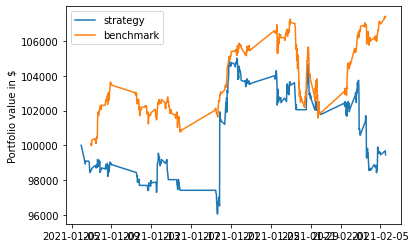

In [48]:
pf.plot_equity_curve(dbal_, benchmark=benchmark_dbal_)

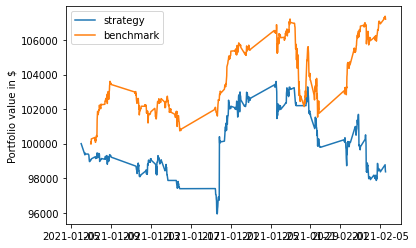

In [57]:
pf.plot_equity_curve(dbal_, benchmark=benchmark_dbal_)